In [1]:
import cv2
import numpy as np

In [2]:
print(cv2.__version__)

4.13.0


In [3]:
from google.colab.patches import cv2_imshow

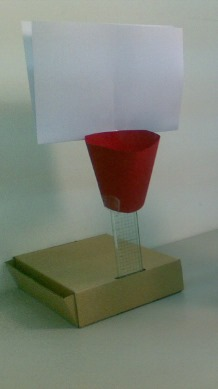

In [4]:
img = cv2.imread('/content/basket.jpeg')
cv2_imshow(img)

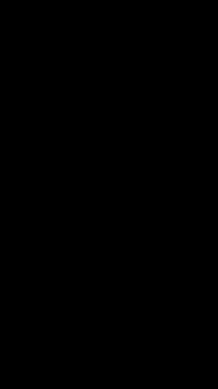

In [5]:
upper = np.array([0,0,50])
lower = np.array([45,45,255])
mask = cv2.inRange(img, lower, upper)
result = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(result)


In [6]:

# cv2.waitKey(0)
# cv2.destroyAllWindows()

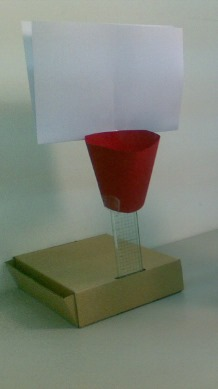

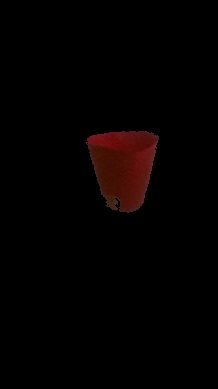

In [7]:
import numpy as np
import cv2
redbasket=cv2.imread('/content/basket.jpeg')
cv2_imshow(redbasket)
redrgb=cv2.cvtColor(redbasket,cv2.COLOR_BGR2RGB)
lower_red1 = np.array([50, 0, 0])
upper_red1 = np.array([255,45, 45])
mask1 = cv2.inRange(redrgb, lower_red1, upper_red1)
res = cv2.bitwise_and(redbasket,redbasket, mask= mask1)
cv2_imshow(res)

In [8]:
# Convert to graycsale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Blur the image for better edge detection
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)


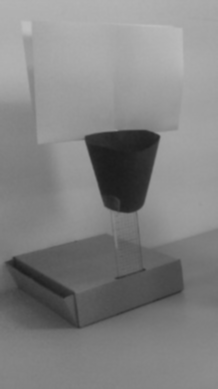

In [9]:
cv2_imshow(img_blur)

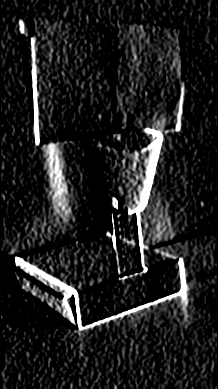

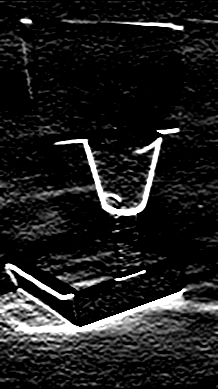

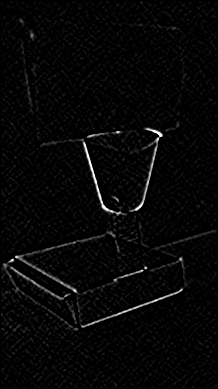

-1

In [10]:
# Sobel Edge Detection
sobelx = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis
sobely = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis
sobelxy = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
# Display Sobel Edge Detection Images
cv2_imshow(sobelx)
cv2.waitKey(0)
cv2_imshow(sobely)
cv2.waitKey(0)
cv2_imshow(sobelxy)
cv2.waitKey(0)


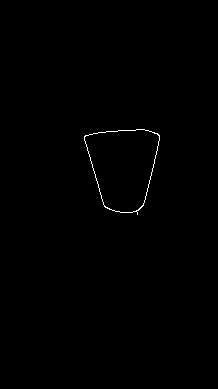

-1

In [11]:
edges = cv2.Canny(image=img_blur, threshold1=100, threshold2=300) # Canny Edge Detection
# Display Canny Edge Detection Image
cv2_imshow(edges)
cv2.waitKey(0)

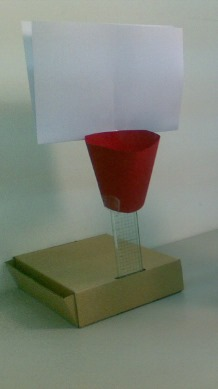

-1

In [12]:
contours, _ = cv2.findContours(img_blur, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(img_blur, contours, -1, (0,255,0), 3)

# # Loop through contours
# for cnt in contours:
#     if len(cnt) > 50:  # need enough points for ellipse
#         ellipse = cv2.fitEllipse(cnt)

#         # Draw ellipse
#         cv2.ellipse(img, ellipse, (0, 255, 0), 2)

cv2_imshow(img)
cv2.waitKey(0)

In [13]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = max(contours, key=cv2.contourArea)

In [14]:
pts = cnt.reshape(-1, 2)

# Find top y (smallest y in image)
y_min = np.min(pts[:, 1])

# Keep points close to top (tune threshold)
threshold = 20
top_pts = pts[pts[:, 1] < y_min + threshold]

In [15]:
top_pts = top_pts[np.argsort(top_pts[:, 0])]

In [16]:
# x = top_pts[:, 0]
# y = top_pts[:, 1]

# # Fit quadratic curve
# coeffs = np.polyfit(x, y, 2)
# poly = np.poly1d(coeffs)

# x_new = np.linspace(x.min(), x.max(), 100)
# y_new = poly(x_new)

In [17]:
# for i in range(len(x_new)-1):
#     pt1 = (int(x_new[i]), int(y_new[i]))
#     pt2 = (int(x_new[i+1]), int(y_new[i+1]))
#     cv2.line(img, pt1, pt2, (0,255,0), 2)

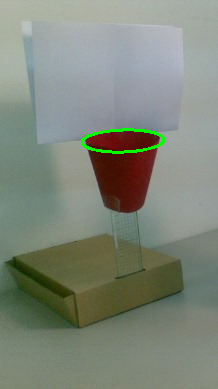

In [18]:
# Convert edges to color image so we can draw colored ellipse
output = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

# Fit and draw ellipse
if len(top_pts) >= 5:
    ellipse = cv2.fitEllipse(top_pts)
    cv2.ellipse(img, ellipse, (0,255,0), 2)

# Show result
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()